# RM / RM+ on Rock-Paper-Scissors
Check regret matching behavior on a tiny toy game.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Define Rock-Scissors-Paper as a normal-form game.

In [2]:
# row: P0 action, col: P1 action
RPS_PAYOFF = np.array([[0.0, -1.0, 1.0], [1.0, 0.0, -1.0], [-1.0, 1.0, 0.0]])


def expected_value(p: np.ndarray, q: np.ndarray) -> float:
    return float(p @ RPS_PAYOFF @ q)


def row_payoffs_vs(q: np.ndarray) -> np.ndarray:
    return RPS_PAYOFF @ q


def col_payoffs_vs(p: np.ndarray) -> np.ndarray:
    return -(p @ RPS_PAYOFF)


def exploitability(p: np.ndarray, q: np.ndarray) -> float:
    # 2p zero-sum matrix game: exploitability = NashConv / 2
    p1_best_response_value = np.max(row_payoffs_vs(q))
    p2_best_response_value = np.max(col_payoffs_vs(p))
    nash_conv = p1_best_response_value + p2_best_response_value
    return float(nash_conv / 2.0)

In [3]:
from regret_matching import RegretMatching


def train(
    steps: int,
    plus: bool = False,
    init_r1: np.ndarray | None = None,
    init_r2: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, float, np.ndarray]:
    rm1 = RegretMatching(3, plus=plus, init_regret=init_r1)
    rm2 = RegretMatching(3, plus=plus, init_regret=init_r2)
    expl_hist = np.zeros(steps)

    for t in range(steps):
        p = rm1.next_strategy()
        q = rm2.next_strategy()

        rm1.observe_utility(row_payoffs_vs(q))
        rm2.observe_utility(col_payoffs_vs(p))

        avg_p = rm1.average_strategy()
        avg_q = rm2.average_strategy()
        expl_hist[t] = exploitability(avg_p, avg_q)

    final_ev = expected_value(avg_p, avg_q)
    return avg_p, avg_q, final_ev, expl_hist


RM
P0 avg strategy: [0.3392, 0.3343, 0.3265]
P1 avg strategy: [0.3302, 0.3315, 0.3383]
Final EV (P0): 2.3e-05
Final exploitability: 0.00977403

RM+
P0 avg strategy: [0.332, 0.3328, 0.3352]
P1 avg strategy: [0.3348, 0.3338, 0.3314]
Final EV (P0): -0.0
Final exploitability: 0.00287796



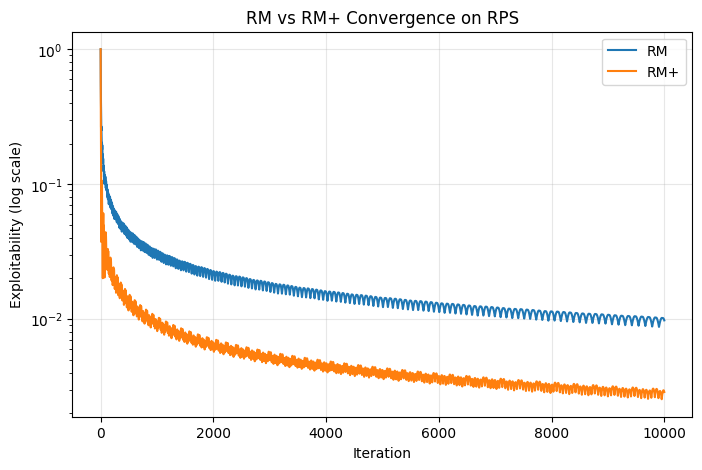

In [4]:
steps = 10000
init_r1 = np.array([0.25, -0.10, -0.15])
init_r2 = np.array([-0.20, 0.30, -0.10])
histories = {}

for plus in [False, True]:
    name = "RM+" if plus else "RM"
    p, q, final_ev, expl_hist = train(
        steps=steps,
        plus=plus,
        init_r1=init_r1,
        init_r2=init_r2,
    )
    histories[name] = expl_hist
    print(name)
    print("P0 avg strategy:", np.round(p, 4).tolist())
    print("P1 avg strategy:", np.round(q, 4).tolist())
    print("Final EV (P0):", round(float(final_ev), 6))
    print("Final exploitability:", f"{expl_hist[-1]:.8f}")
    print()

iters = np.arange(1, steps + 1)
eps = 1e-12

plt.figure(figsize=(8, 5))
for name in ["RM", "RM+"]:
    plt.plot(iters, np.maximum(histories[name], eps), label=name)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Exploitability (log scale)")
plt.title("RM vs RM+ Convergence on RPS")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()